<class 'pandas.core.frame.DataFrame'>
Index: 33587 entries, 1 to 56610
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Subject   33587 non-null  object        
 1   Message   33587 non-null  object        
 2   Spam/Ham  33587 non-null  object        
 3   Date      33587 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 1.3+ MB
None
                        Subject  \
1      vastar resources , inc .   
2  calpine daily gas nomination   
3                    re : issue   
4     meter 7268 nov allocation   
5      mcmullen gas for 11 / 99   

                                             Message Spam/Ham       Date  
1  gary , production from the high island larger ...      ham 1999-12-13  
2             - calpine daily gas nomination 1 . doc      ham 1999-12-14  
3  fyi - see note below - already done .\nstella\...      ham 1999-12-14  
4  fyi .\n- - - - - - - - - - - - - - - - - - 

/tmp/ipykernel_856/4093559829.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


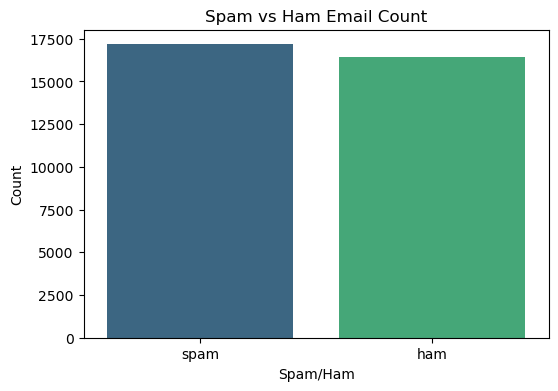

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only relevant columns
df_small = df[['Subject', 'Message', 'Spam/Ham', 'Date']].copy()

# Check basic info
print(df_small.info())
print(df_small.head())

# Count of ham vs spam
label_counts = df_small['Spam/Ham'].value_counts()
print(label_counts)

# Plot label distribution
plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.ylabel("Count")
plt.title("Spam vs Ham Email Count")
plt.show()


In [28]:
df_small = df[['Subject', 'Message', 'Spam/Ham', 'Date']].copy()

import re

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'\r\n', ' ', text)              # remove newlines
    text = re.sub(r'[^a-z0-9@$% ]', ' ', text)    # keep letters, numbers, some symbols
    text = ' '.join(text.split())                  # remove extra spaces
    return text

# Create 'clean_text' column
df_small['clean_text'] = df_small['Message'].apply(clean_text)


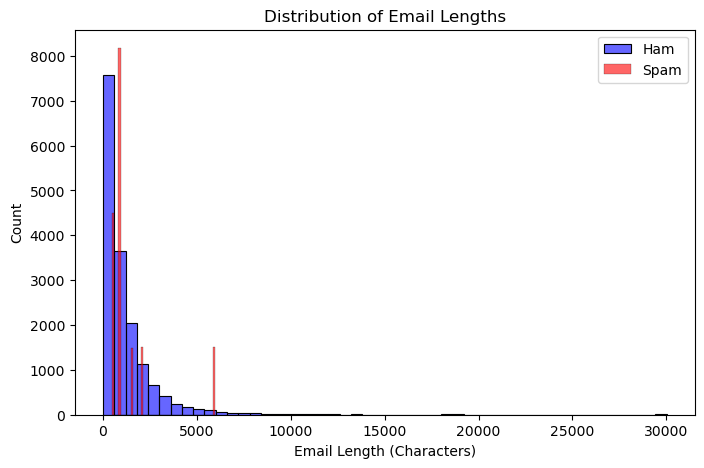

In [29]:
# Add a column for text length
df_small['text_length'] = df_small['clean_text'].apply(len)

# Plot histogram of email lengths
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_small[df_small['Spam/Ham']=='ham']['text_length'], color='blue', label='Ham', bins=50, alpha=0.6)
sns.histplot(df_small[df_small['Spam/Ham']=='spam']['text_length'], color='red', label='Spam', bins=50, alpha=0.6)
plt.xlabel("Email Length (Characters)")
plt.ylabel("Count")
plt.title("Distribution of Email Lengths")
plt.legend()
plt.show()


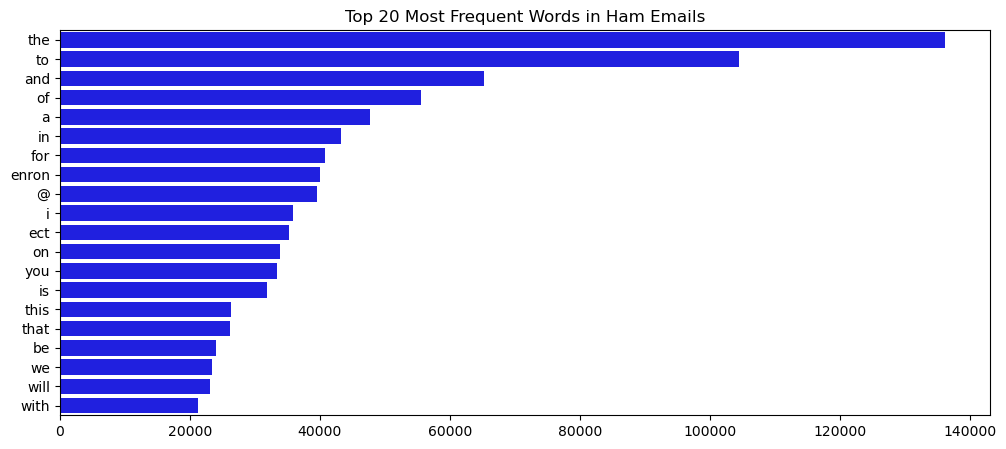

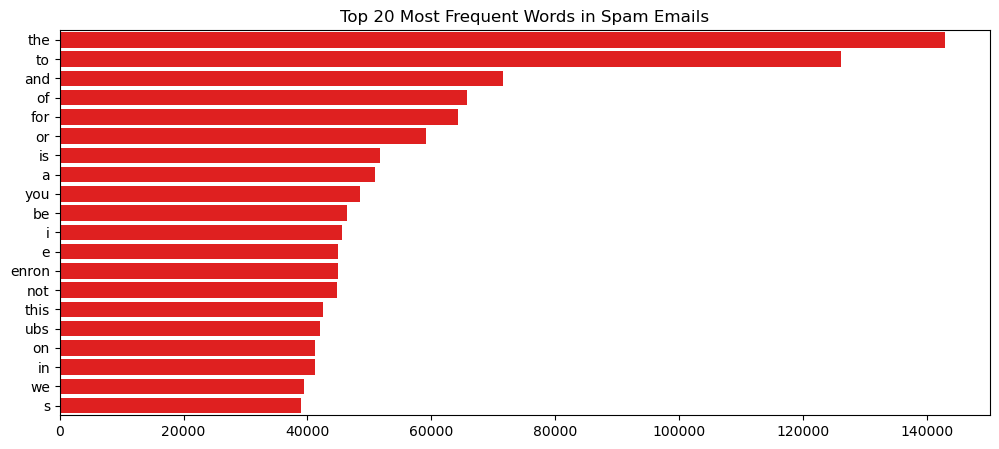

In [31]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Split words for ham and spam
ham_words = " ".join(df_small[df_small['Spam/Ham']=='ham']['clean_text']).split()
spam_words = " ".join(df_small[df_small['Spam/Ham']=='spam']['clean_text']).split()

# Count most common words
ham_common = Counter(ham_words).most_common(20)
spam_common = Counter(spam_words).most_common(20)

# Plot top 20 words for Ham
plt.figure(figsize=(12,5))
sns.barplot(x=[x[1] for x in ham_common], y=[x[0] for x in ham_common], color='blue')
plt.title("Top 20 Most Frequent Words in Ham Emails")
plt.show()

# Plot top 20 words for Spam
plt.figure(figsize=(12,5))
sns.barplot(x=[x[1] for x in spam_common], y=[x[0] for x in spam_common], color='red')
plt.title("Top 20 Most Frequent Words in Spam Emails")
plt.show()


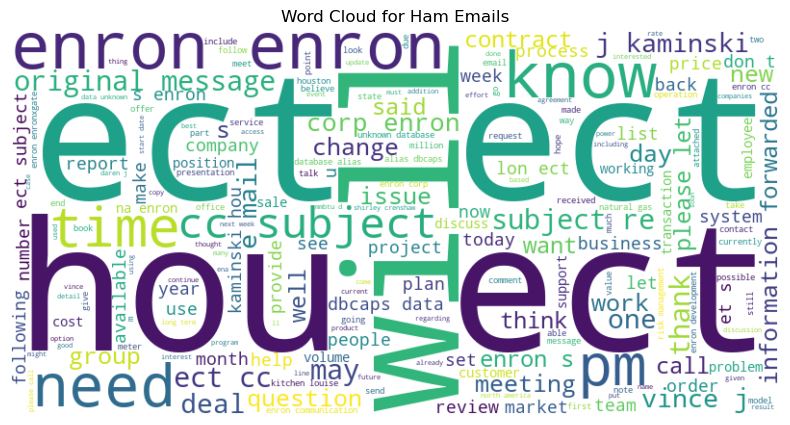

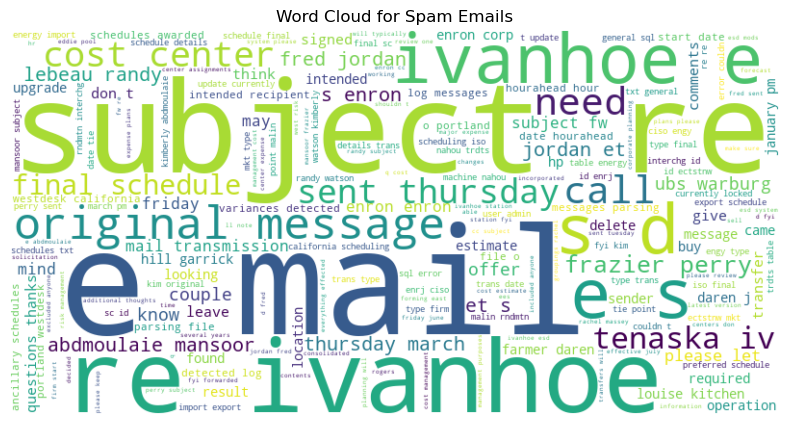

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ham word cloud
ham_text = " ".join(df_small[df_small['Spam/Ham']=='ham']['clean_text'])
spam_text = " ".join(df_small[df_small['Spam/Ham']=='spam']['clean_text'])

# Ham word cloud
plt.figure(figsize=(10,5))
wordcloud_ham = WordCloud(width=800, height=400, background_color='white').generate(ham_text)
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Ham Emails")
plt.show()

# Spam word cloud
plt.figure(figsize=(10,5))
wordcloud_spam = WordCloud(width=800, height=400, background_color='white').generate(spam_text)
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Spam Emails")
plt.show()
